In [ ]:
!pip install underthesea gensim fasttext emoji lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 38.2 MB/s eta 0:00:00
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.0 MB/s eta 0:00:00
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653909 sha256=5dfcf874ea493b242f1ffb4dc5c5f717ed14f4ce0a877bacb83ef682f918112e
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import fasttext
import emoji
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, roc_auc_score,
    average_precision_score, auc, brier_score_loss
)
from sklearn.calibration import calibration_curve
from underthesea import word_tokenize

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CommentClassificationDataset/train_full.csv"
data = pd.read_csv(DATA_PATH)

print(data.columns)
print(data.head())
print("\nCount:\n", data["is_violation"].value_counts(dropna=False))
print("\nRatio:\n", data["is_violation"].value_counts(normalize=True, dropna=False))

data["comment"] = data["comment"].astype(str).fillna("")
data["is_violation"] = data["is_violation"].astype(int)

original_comments = data['comment'].values
y = data['is_violation'].values

Index(['comment', 'is_violation'], dtype='object')
                                             comment  is_violation
0                                                cặc           1.0
1                   đr hết thời cày rank bk còn ngợp           0.0
2         Diễn viên hô ni hút mà ngại gì mấy khác kk           0.0
3  Toàn bọn vô công rồi nghề ngồi sủa ăn lương th...           1.0
4  lên kim cương bố ỉa vào mồm mày với cái lối lê...           1.0

Count:
 is_violation
1.0    3668
0.0    2684
Name: count, dtype: int64

Ratio:
 is_violation
1.0    0.577456
0.0    0.422544
Name: proportion, dtype: float64


In [ ]:
def preprocess_basic(text):
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return tokens

data['tokens'] = data['comment'].apply(preprocess_basic)
print("Sample tokens:", data['tokens'].iloc[0])

X_tokens = data['tokens'].values

Sample tokens: ['cặc']


In [ ]:
indices = np.arange(len(data))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=42
)

X_train = X_tokens[train_idx]
X_val = X_tokens[val_idx]
X_test = X_tokens[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

train_comments = original_comments[train_idx]
val_comments = original_comments[val_idx]
test_comments = original_comments[test_idx]

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

print("TRAIN ratio:\n", pd.Series(y_train).value_counts(normalize=True))
print("VAL ratio:\n", pd.Series(y_val).value_counts(normalize=True))
print("TEST ratio:\n", pd.Series(y_test).value_counts(normalize=True))

Train: 4446
Val  : 953
Test : 953
TRAIN ratio:
 1    0.577373
0    0.422627
Name: proportion, dtype: float64
VAL ratio:
 1    0.578174
0    0.421826
Name: proportion, dtype: float64
TEST ratio:
 1    0.577125
0    0.422875
Name: proportion, dtype: float64


In [ ]:
!wget -O cc.vi.300.bin.gz https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.bin.gz
!gunzip -f cc.vi.300.bin.gz

ft_model = fasttext.load_model('cc.vi.300.bin')
print("FastText model loaded. Vector dimension:", ft_model.get_dimension())

--2026-05-08 15:24:29--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.84.118.30, 99.84.118.117, 99.84.118.67, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.84.118.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4504817955 (4.2G) [application/octet-stream]
Saving to: ‘cc.vi.300.bin.gz’

cc.vi.300.bin.gz    100%[===================>]   4.20G   163MB/s    in 34s     

2026-05-08 15:25:03 (126 MB/s) - ‘cc.vi.300.bin.gz’ saved [4504817955/4504817955]

FastText model loaded. Vector dimension: 300


In [ ]:
train_strings = [' '.join(tokens) for tokens in X_train]
val_strings = [' '.join(tokens) for tokens in X_val]
test_strings = [' '.join(tokens) for tokens in X_test]

tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', min_df=1, max_df=1.0)
tfidf.fit(train_strings)

def get_weighted_average_vector(sentence, tfidf_vectorizer, w2v_model, vec_size=300):
    tfidf_vec = tfidf_vectorizer.transform([sentence])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    weights = tfidf_vec.toarray()[0]
    weighted_sum = np.zeros(vec_size)
    total_weight = 0.0
    for word, w in zip(feature_names, weights):
        if w > 0:
            vec = w2v_model.get_word_vector(word)
            weighted_sum += w * vec
            total_weight += w
    if total_weight > 0:
        return weighted_sum / total_weight
    else:
        return np.zeros(vec_size)

X_train_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in train_strings])
X_val_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in val_strings])
X_test_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in test_strings])

print("Shape X_train_vec:", X_train_vec.shape)

Shape X_train_vec: (4446, 300)


In [ ]:
# Định nghĩa grid tham số
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.0, 0.1]
}

# Tạo model cơ bản
lgb_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# GridSearchCV với 3-fold (để nhanh hơn)
grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("===== BẮT ĐẦU GRID SEARCH LIGHTGBM =====")
grid_search.fit(X_train_vec, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

# Lấy model tốt nhất
lgb_model = grid_search.best_estimator_
print("LightGBM with best params training completed.")

===== BẮT ĐẦU GRID SEARCH LIGHTGBM =====
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0.0, 'reg_lambda': 0.1}
Best CV F1: 0.8465808341095838
LightGBM with best params training completed.


In [ ]:
y_val_prob = lgb_model.predict_proba(X_val_vec)[:, 1]

cost_configs = [
    {"name": "cost_1_5", "fp": 1.0, "fn": 5.0},
    {"name": "cost_1_3", "fp": 1.0, "fn": 3.0},
    {"name": "cost_1_2", "fp": 1.0, "fn": 2.0},
    {"name": "cost_2_5", "fp": 2.0, "fn": 5.0},
]
fixed_thresholds = [0.30, 0.32, 0.35, 0.38, 0.40, 0.42]

def evaluate_threshold(y_true, y_prob, thresh, cost_fp, cost_fn):
    y_pred = (y_prob >= thresh).astype(int)
    n_pos = np.sum(y_true)
    n_neg = len(y_true) - n_pos
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = n_pos - tp
    tn = n_neg - fp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / n_pos if n_pos > 0 else 0
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    cost = fp * cost_fp + fn * cost_fn
    return {"threshold": thresh, "precision": prec, "recall": rec, "f1": f1, "fp": fp, "fn": fn, "cost": cost}

candidates = []
for cfg in cost_configs:
    prec, rec, thresholds = precision_recall_curve(y_val, y_val_prob)
    best_cost = np.inf
    best_info = None
    for i, th in enumerate(thresholds):
        info = evaluate_threshold(y_val, y_val_prob, th, cfg["fp"], cfg["fn"])
        if info["cost"] < best_cost:
            best_cost = info["cost"]
            best_info = info
    candidates.append(best_info)

for th in fixed_thresholds:
    info = evaluate_threshold(y_val, y_val_prob, th, 1.0, 5.0)
    candidates.append(info)

print("\n===== CANDIDATE THRESHOLDS (on validation) =====")
for cand in candidates:
    print(f"th={cand['threshold']:.4f} | prec={cand['precision']:.4f} | rec={cand['recall']:.4f} | f1={cand['f1']:.4f} | fp={cand['fp']} | fn={cand['fn']}")

# Chọn ngưỡng có F1 cao nhất (không ràng buộc recall)
best_candidate = max(candidates, key=lambda x: x['f1'])
best_threshold = best_candidate['threshold']
print(f"\n=== Chọn ngưỡng theo F1 max: {best_threshold:.4f} (F1={best_candidate['f1']:.4f}, precision={best_candidate['precision']:.4f}, recall={best_candidate['recall']:.4f}) ===")


===== CANDIDATE THRESHOLDS (on validation) =====
th=0.1151 | prec=0.7397 | rec=0.9746 | f1=0.8410 | fp=189 | fn=14
th=0.1219 | prec=0.7434 | rec=0.9728 | f1=0.8428 | fp=185 | fn=15
th=0.3258 | prec=0.8353 | rec=0.9201 | f1=0.8756 | fp=100 | fn=44
th=0.3258 | prec=0.8353 | rec=0.9201 | f1=0.8756 | fp=100 | fn=44
th=0.3000 | prec=0.8247 | rec=0.9220 | f1=0.8706 | fp=108 | fn=43
th=0.3200 | prec=0.8311 | rec=0.9201 | f1=0.8734 | fp=103 | fn=44
th=0.3500 | prec=0.8463 | rec=0.9093 | f1=0.8766 | fp=91 | fn=50
th=0.3800 | prec=0.8532 | rec=0.8966 | f1=0.8743 | fp=85 | fn=57
th=0.4000 | prec=0.8629 | rec=0.8911 | f1=0.8768 | fp=78 | fn=60
th=0.4200 | prec=0.8703 | rec=0.8893 | f1=0.8797 | fp=73 | fn=61

=== Chọn ngưỡng theo F1 max: 0.4200 (F1=0.8797, precision=0.8703, recall=0.8893) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


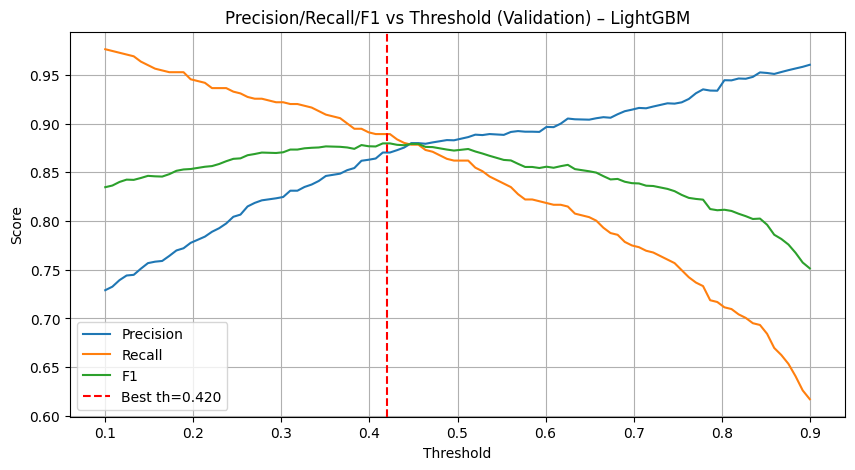

In [ ]:
thresholds = np.linspace(0.1, 0.9, 100)
precs = []
recs = []
f1s = []
for th in thresholds:
    y_pred = (y_val_prob >= th).astype(int)
    tp = np.sum((y_val == 1) & (y_pred == 1))
    fp = np.sum((y_val == 0) & (y_pred == 1))
    fn = np.sum((y_val == 1) & (y_pred == 0))
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    rec = tp / np.sum(y_val) if np.sum(y_val)>0 else 0
    f1 = 2*prec*rec/(prec+rec+1e-8)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)

plt.figure(figsize=(10,5))
plt.plot(thresholds, precs, label='Precision')
plt.plot(thresholds, recs, label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best th={best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Validation) – LightGBM')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_model(model, X_vec, y_true, threshold, split_name="DATA"):
    y_prob = model.predict_proba(X_vec)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    print(f"\n===== {split_name} =====")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print(confusion_matrix(y_true, y_pred))
    return y_prob, y_pred

In [ ]:
y_train_prob, y_train_pred = evaluate_model(lgb_model, X_train_vec, y_train, best_threshold, "TRAIN")
y_val_prob, y_val_pred = evaluate_model(lgb_model, X_val_vec, y_val, best_threshold, "VALIDATION")
y_test_prob, y_test_pred = evaluate_model(lgb_model, X_test_vec, y_test, best_threshold, "TEST")


===== TRAIN =====
ROC-AUC : 1.0000
PR-AUC  : 1.0000
              precision    recall  f1-score   support

           0     0.9995    0.9995    0.9995      1879
           1     0.9996    0.9996    0.9996      2567

    accuracy                         0.9996      4446
   macro avg     0.9995    0.9995    0.9995      4446
weighted avg     0.9996    0.9996    0.9996      4446

[[1878    1]
 [   1 2566]]

===== VALIDATION =====
ROC-AUC : 0.9275
PR-AUC  : 0.9476
              precision    recall  f1-score   support

           0     0.8436    0.8184    0.8308       402
           1     0.8703    0.8893    0.8797       551

    accuracy                         0.8594       953
   macro avg     0.8570    0.8539    0.8553       953
weighted avg     0.8591    0.8594    0.8591       953

[[329  73]
 [ 61 490]]

===== TEST =====
ROC-AUC : 0.9194
PR-AUC  : 0.9425
              precision    recall  f1-score   support

           0     0.8234    0.7866    0.8046       403
           1     0.8486 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


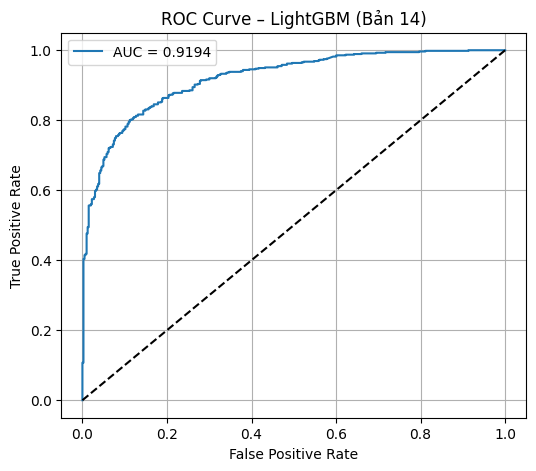

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM (Bản 14)")
plt.legend()
plt.grid(True)
plt.show()

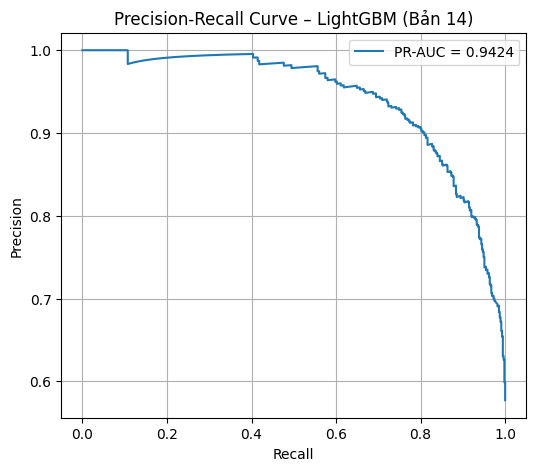

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – LightGBM (Bản 14)")
plt.legend()
plt.grid(True)
plt.show()

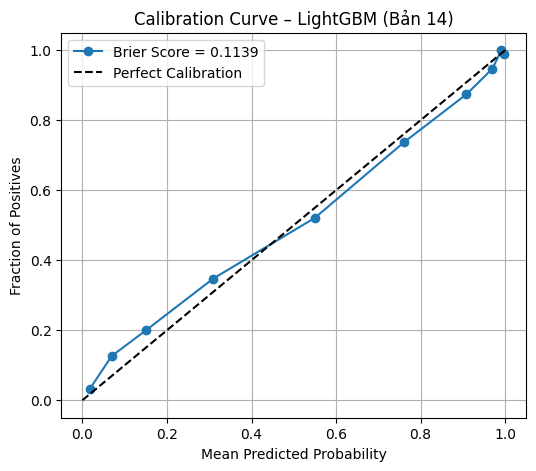

In [ ]:
frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker='o', label=f"Brier Score = {brier:.4f}")
plt.plot([0,1],[0,1], 'k--', label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve – LightGBM (Bản 14)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cv_scores = cross_validate(
    lgb_model,  # dùng model đã tối ưu (best_params)
    X_train_vec, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    return_train_score=False,
    n_jobs=-1
)

print("\n===== CROSS-VALIDATION (5-fold) – LightGBM (Bản 14) =====")
for metric in cv_scores:
    if metric.startswith("test_"):
        vals = cv_scores[metric]
        print(f"{metric}: {vals.mean():.4f} +/- {vals.std():.4f}")


===== CROSS-VALIDATION (5-fold) – LightGBM (Bản 14) =====
test_accuracy: 0.8225 +/- 0.0089
test_precision: 0.8483 +/- 0.0112
test_recall: 0.8438 +/- 0.0158
test_f1: 0.8459 +/- 0.0082
test_roc_auc: 0.9053 +/- 0.0116
test_pr_auc: 0.9309 +/- 0.0112


In [ ]:
def show_fp_fn_samples_comments(comments, y_true, y_pred, y_prob, n=10):
    df = pd.DataFrame({
        "comment": comments,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_violation": y_prob
    })
    fp = df[(df["true_label"] == 0) & (df["pred_label"] == 1)]
    fn = df[(df["true_label"] == 1) & (df["pred_label"] == 0)]

    print(f"\n===== FALSE POSITIVES (Total: {len(fp)}) – LightGBM (Bản 14) =====")
    if len(fp) > 0:
        print(fp.sort_values("prob_violation", ascending=False).head(n)[["prob_violation", "comment"]])
    else:
        print("No false positives found!")

    print(f"\n===== FALSE NEGATIVES (Total: {len(fn)}) – LightGBM (Bản 14) =====")
    if len(fn) > 0:
        print(fn.sort_values("prob_violation", ascending=True).head(n)[["prob_violation", "comment"]])
    else:
        print("No false negatives found!")

show_fp_fn_samples_comments(test_comments, y_test, y_test_pred, y_test_prob, n=10)


===== FALSE POSITIVES (Total: 86) – LightGBM (Bản 14) =====
     prob_violation                                            comment
310        0.997746  Mày coi lại não mày load hết được cmt tao chưa...
259        0.973884                                        chó bị bệnh
84         0.972750      ma ba vang ngoc noi thiet khg bao gio noi doc
142        0.972042                 TRAN DAN TIEN BO.MOI GIA NHAP DCS.
739        0.961882  Xin đừng tin ai ở cái xã hội này-lừa đảo , cướ...
462        0.957817  Cứ bắt rồi thả về lại đi hành nghề trộm cắp th...
69         0.927453                   cái trình đct 275đ =)) tự hào qá
93         0.927010  Mai Hà vậy mày coi lại bình luận đầu tiên của ...
439        0.925283            Khánh An hạt điên quỷ tới chơi nè lũ bk
170        0.921104                               Mày nghĩ xl là hết à

===== FALSE NEGATIVES (Total: 68) – LightGBM (Bản 14) =====
     prob_violation                                            comment
418        0.009991  r, hi